# Highland Square Conjoint — Notebook 2: Analyze & Visualize

**Pipeline (this notebook):**
1. Load and parse raw responses (extract A/B/C/D choices)
2. Reshape into long format with outside option (D) as baseline
3. Fit a mixed logit model (Size & Price continuous, rest categorical)
4. Compute marginal Willingness-to-Pay (WTP) per attribute level
5. Visualize: relative importance, zero-centered part-worths, dollar WTP
6. Market-share simulator for Highland Square repositioning scenarios

**Input:** `data/raw_responses.csv` (from Notebook 1)
**Outputs:** WTP tables, plots (PNG), simulator function ready for IC memo

## 0. Setup

In [1]:
# Install if needed (xlogit is the mixed logit estimator)
!pip install xlogit --quiet

In [2]:
import os
import re
import json
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from xlogit import MixedLogit, MultinomialLogit

warnings.filterwarnings('ignore')

DATA_DIR = Path("data")
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

print("Setup complete.")

Setup complete.


## 1. Re-import the design spec

We need the ATTRIBUTES dict from Notebook 1 to know which attributes are continuous vs. categorical, and the numeric values for Size/Price.

In [3]:
# Paste the locked ATTRIBUTES dict here (same as Notebook 1)
ATTRIBUTES = {
    "Size": {
        "750 SF (compact 1BR)": 750,
        "1,000 SF (large 1BR / compact 2BR)": 1000,
        "1,250 SF (standard 2BR)": 1250,
    },
    "Price": {
        "$1,650/mo": 1650,
        "$1,950/mo": 1950,
        "$2,250/mo": 2250,
        "$2,550/mo": 2550,
    },
    "MoveInSpecial": {
        "None": None,
        "1 month free (12-mo lease)": None,
        "2 months free (13-mo lease)": None,
    },
    "Location": {
        "North Druid Hills / Briarcliff": None,
        "Virginia-Highland / Morningside": None,
        "Decatur / Emory Village": None,
        "Buckhead / Lenox": None,
    },
    "CommuteToWork": {
        "Quick (under 15 minutes to your daily destination)": None,
        "Average (15-30 minutes to your daily destination)": None,
        "Long (30-45 minutes to your daily destination)": None,
    },
    "Walkability": {
        "Car-Required (drive for groceries, dining, errands from this building)": None,
        "Walkable Errands (groceries & a few restaurants within a 10-min walk of this building)": None,
        "Walk Everywhere (daily errands, dining, transit within a 10-min walk of this building)": None,
    },
    "Finishes": {
        "Builder-grade (laminate counters, basic appliances, no smart features)": None,
        "Mid-tier (granite/quartz counters, stainless appliances, in-unit washer/dryer)": None,
        "Premium (quartz waterfall island, smart thermostat, keyless entry, video doorbell)": None,
    },
    "Parking": {
        "Surface lot, unassigned parking, no gate": None,
        "Gated surface lot + reserved space option": None,
        "Dedicated garage with assigned space + EV charging": None,
    },
    "Security": {
        "Tier 1: Open access, no controlled entry": None,
        "Tier 2: Perimeter gate + controlled-access lobby + camera coverage": None,
        "Tier 3: Tier 2 + 24/7 staff or virtual concierge + smart locks throughout": None,
    },
    "Rooftop": {
        "No rooftop space": None,
        "Rooftop lounge with skyline views & outdoor seating": None,
    },
    "Coworking": {
        "No dedicated coworking space": None,
        "Resident co-working lounge with private call rooms & wifi": None,
    },
    "PetAmenities": {
        "No pet amenities": None,
        "Standard dog park only": None,
        "Dog park + pet spa with grooming station": None,
    },
    "PackageHandling": {
        "Standard mailroom (sign for packages during office hours)": None,
        "24/7 Amazon Hub lockers + refrigerated grocery locker": None,
    },
}

attr_names = list(ATTRIBUTES.keys())
CONTINUOUS_ATTRS = [a for a in attr_names if any(v is not None for v in ATTRIBUTES[a].values())]
CATEGORICAL_ATTRS = [a for a in attr_names if a not in CONTINUOUS_ATTRS]

print(f"Continuous attributes: {CONTINUOUS_ATTRS}")
print(f"Categorical attributes: {CATEGORICAL_ATTRS}")

Continuous attributes: ['Size', 'Price']
Categorical attributes: ['MoveInSpecial', 'Location', 'CommuteToWork', 'Walkability', 'Finishes', 'Parking', 'Security', 'Rooftop', 'Coworking', 'PetAmenities', 'PackageHandling']


## 2. Load Raw Responses and Parse Choices

In [4]:
raw_df = pd.read_csv(DATA_DIR / "raw_responses.csv")
print(f"Total rows: {len(raw_df)}")
print(f"Errors: {raw_df['Error'].notna().sum()}")
print(f"Personas: {raw_df['Persona'].unique().tolist()}")
raw_df.head(3)

Total rows: 7200
Errors: 0
Personas: ['emory_grad', 'vahi_professional', 'empty_nester', 'skeptical_renter_control']


,Task_ID,Persona,Rep,Shuffled_Profiles,Response,Error
0,0,emory_grad,0,"[{""Size"": ""1,000 SF (large 1BR / compact 2BR)""...","B\n\nAs a PhD candidate with tight finances, t...",NaN
1,0,emory_grad,1,"[{""Size"": ""1,000 SF (large 1BR / compact 2BR)""...","C. The $300/month savings ($3,600/year) is mea...",NaN
2,0,emory_grad,2,"[{""Size"": ""1,000 SF (large 1BR / compact 2BR)""...",B\n\nMy short commute to Emory (under 15 min) ...,NaN


In [5]:
# Drop error rows
df = raw_df[raw_df['Error'].isna()].copy()
print(f"Successful responses: {len(df)}")

# Parse choice letter (A/B/C/D) from response text
def parse_choice(text):
    if pd.isna(text):
        return None
    # Look for letter at start, in bold, or as standalone token in first 50 chars
    m = re.search(r'\b([ABCD])\b', str(text)[:50])
    return m.group(1) if m else None

df['Choice'] = df['Response'].apply(parse_choice)
parseable = df['Choice'].notna().sum()
print(f"Parseable choices: {parseable} ({100*parseable/len(df):.1f}%)")
print(f"\nChoice distribution:")
print(df['Choice'].value_counts())

# Keep only parseable
df = df[df['Choice'].notna()].copy()
print(f"\nFinal usable rows: {len(df)}")

Successful responses: 7200
Parseable choices: 7200 (100.0%)

Choice distribution:
Choice
B    3012
C    2263
A    1925
Name: count, dtype: int64

Final usable rows: 7200


In [6]:
# Diagnostic: choice distribution by persona
print("Choice distribution by persona:\n")
ct = pd.crosstab(df['Persona'], df['Choice'], normalize='index') * 100
print(ct.round(1))

print("\nKey check: D-rate (outside option) by persona")
print("  - Maya (emory_grad) should be highest (budget-constrained)")
print("  - Patricia (empty_nester) should be lowest (wealthy)")
if 'D' in ct.columns:
    print(f"\n  Observed D rates:")
    print(ct['D'].sort_values(ascending=False).round(1))

Choice distribution by persona:

Choice                       A     B     C
Persona                                   
emory_grad                27.3  41.1  31.6
empty_nester              22.0  43.9  34.1
skeptical_renter_control  27.8  40.9  31.3
vahi_professional         29.9  41.3  28.8

Key check: D-rate (outside option) by persona
  - Maya (emory_grad) should be highest (budget-constrained)
  - Patricia (empty_nester) should be lowest (wealthy)


In [8]:
# Did B win because it was systematically the "best" card, 
# or because the LLM has a positional bias?

# Step 1: What attributes does each position (A/B/C) tend to have?
# This requires linking back to the actual profiles shown for each choice.

import json

# Build a position-level summary
position_summary = []
for _, row in df.iterrows():
    profiles = json.loads(row['Shuffled_Profiles']) if isinstance(row['Shuffled_Profiles'], str) else row['Shuffled_Profiles']
    for j, profile in enumerate(profiles):
        alt_label = chr(ord('A') + j)
        position_summary.append({
            'Position': alt_label,
            'Persona': row['Persona'],
            'Price': ATTRIBUTES['Price'][profile['Price']],
            'Size': ATTRIBUTES['Size'][profile['Size']],
            'WasChosen': 1 if row['Choice'] == alt_label else 0,
        })

pos_df = pd.DataFrame(position_summary)

# Average price per position — if shuffling worked, all 3 positions should average ~$2,100
print("Average price by position (should be similar across A/B/C if shuffling worked):")
print(pos_df.groupby('Position')['Price'].mean().round(0))

# Choice rate per position
print("\nChoice rate by position (should be near 33% if no positional bias):")
print((pos_df.groupby('Position')['WasChosen'].mean() * 100).round(1))

# Choice rate per position, conditional on price
print("\nChoice rate by (position × price quartile):")
pos_df['PriceQ'] = pd.qcut(pos_df['Price'], q=4, labels=['Q1-cheap', 'Q2', 'Q3', 'Q4-expensive'])
print((pos_df.groupby(['Position', 'PriceQ'])['WasChosen'].mean() * 100).round(1).unstack())

Average price by position (should be similar across A/B/C if shuffling worked):
Position
A    2096.0
B    2099.0
C    2105.0
Name: Price, dtype: float64

Choice rate by position (should be near 33% if no positional bias):
Position
A    26.7
B    41.8
C    31.4
Name: WasChosen, dtype: float64

Choice rate by (position × price quartile):
PriceQ    Q1-cheap    Q2    Q3  Q4-expensive
Position                                    
A             44.1  26.4  20.7          15.0
B             61.4  42.5  37.5          25.8
C             51.4  37.0  22.3          15.8


## 3. Reshape to Long Format

Each choice task becomes 4 rows (A, B, C, D). The chosen alternative gets `choice=1`, others get `choice=0`. The outside option D gets dummy levels (all categorical attributes = baseline, Size and Price = 0). This is the standard encoding for conditional logit with an outside option.

In [9]:
# Build a unique observation ID per (Persona, Task_ID, Rep)
df['ObsID'] = df.apply(
    lambda r: f"{r['Persona']}_t{r['Task_ID']}_r{r['Rep']}",
    axis=1
)
print(f"Unique observations: {df['ObsID'].nunique()}")

# Parse shuffled profiles (saved as JSON in Notebook 1)
df['Profiles'] = df['Shuffled_Profiles'].apply(json.loads)

# Verify each task has 3 profiles
profile_counts = df['Profiles'].apply(len)
print(f"All tasks have 3 profiles: {(profile_counts == 3).all()}")

Unique observations: 7200
All tasks have 3 profiles: True


In [10]:
# Expand each row into 4 alternatives (A, B, C, D-outside-option)
long_rows = []
for _, row in df.iterrows():
    chosen = row['Choice']
    obs_id = row['ObsID']
    persona = row['Persona']
    profiles = row['Profiles']

    # Alternatives A, B, C
    for j, profile in enumerate(profiles):
        alt_label = chr(ord('A') + j)
        rec = {
            'ObsID': obs_id,
            'Persona': persona,
            'Alt': alt_label,
            'choice': 1 if chosen == alt_label else 0,
        }
        # Add attribute values from the profile
        for attr in attr_names:
            rec[attr] = profile[attr]
        # Numeric values for continuous attrs
        rec['Size_num'] = ATTRIBUTES['Size'][profile['Size']]
        rec['Price_num'] = ATTRIBUTES['Price'][profile['Price']]
        long_rows.append(rec)
    
    # Outside option D — encode as all baseline levels, Size and Price = 0
    # The intercept (alternative-specific constant for D) will capture the
    # baseline utility of "keep searching / stay where I am"
    rec_d = {
        'ObsID': obs_id,
        'Persona': persona,
        'Alt': 'D',
        'choice': 1 if chosen == 'D' else 0,
        'Size_num': 0,
        'Price_num': 0,
    }
    # Baseline level for each categorical attr (first level by ATTRIBUTES dict order)
    for attr in attr_names:
        baseline = list(ATTRIBUTES[attr].keys())[0]
        rec_d[attr] = baseline
    long_rows.append(rec_d)

long_df = pd.DataFrame(long_rows)
print(f"Long format rows: {len(long_df)} (expected: {len(df) * 4} = {len(df)} obs × 4 alts)")
print(f"Sum of choice column: {long_df['choice'].sum()} (should equal {len(df)})")
long_df.head(8)

Long format rows: 28800 (expected: 28800 = 7200 obs × 4 alts)
Sum of choice column: 7200 (should equal 7200)


,ObsID,Persona,Alt,choice,Size,Price,MoveInSpecial,Location,CommuteToWork,Walkability,Finishes,Parking,Security,Rooftop,Coworking,PetAmenities,PackageHandling,Size_num,Price_num
0,emory_grad_t0_r0,emory_grad,A,0,"1,000 SF (large 1BR / compact 2BR)","$2,550/mo",2 months free (13-mo lease),Decatur / Emory Village,Average (15-30 min by car),Walkable Errands (groceries & a few restaurant...,"Mid-tier (granite/quartz counters, stainless a...",Dedicated garage with assigned space + EV char...,Tier 3: Tier 2 + 24/7 staff or virtual concier...,Rooftop lounge with skyline views & outdoor se...,No dedicated coworking space,Dog park + pet spa with grooming station,24/7 Amazon Hub lockers + refrigerated grocery...,1000,2550
1,emory_grad_t0_r0,emory_grad,B,1,"1,250 SF (standard 2BR)","$2,250/mo",None,Virginia-Highland / Morningside,Quick (under 15 min by car),"Car-Required (drive for groceries, dining, err...","Mid-tier (granite/quartz counters, stainless a...",Gated surface lot + reserved space option,"Tier 1: Open access, no controlled entry",No rooftop space,No dedicated coworking space,Standard dog park only,24/7 Amazon Hub lockers + refrigerated grocery...,1250,2250
2,emory_grad_t0_r0,emory_grad,C,0,"1,000 SF (large 1BR / compact 2BR)","$2,550/mo",1 month free (12-mo lease),Decatur / Emory Village,Long (over 30 min by car),"Walk Everywhere (daily errands, dining, transi...","Mid-tier (granite/quartz counters, stainless a...","Surface lot, unassigned parking, no gate",Tier 2: Perimeter gate + controlled-access lob...,Rooftop lounge with skyline views & outdoor se...,Resident co-working lounge with private call r...,No pet amenities,Standard mailroom (sign for packages during of...,1000,2550
3,emory_grad_t0_r0,emory_grad,D,0,750 SF (compact 1BR),"$1,650/mo",None,North Druid Hills / Briarcliff,Quick (under 15 minutes to your daily destinat...,"Car-Required (drive for groceries, dining, err...","Builder-grade (laminate counters, basic applia...","Surface lot, unassigned parking, no gate","Tier 1: Open access, no controlled entry",No rooftop space,No dedicated coworking space,No pet amenities,Standard mailroom (sign for packages during of...,0,0
4,emory_grad_t0_r1,emory_grad,A,0,"1,000 SF (large 1BR / compact 2BR)","$2,550/mo",1 month free (12-mo lease),Decatur / Emory Village,Long (over 30 min by car),"Walk Everywhere (daily errands, dining, transi...","Mid-tier (granite/quartz counters, stainless a...","Surface lot, unassigned parking, no gate",Tier 2: Perimeter gate + controlled-access lob...,Rooftop lounge with skyline views & outdoor se...,Resident co-working lounge with private call r...,No pet amenities,Standard mailroom (sign for packages during of...,1000,2550
5,emory_grad_t0_r1,emory_grad,B,0,"1,000 SF (large 1BR / compact 2BR)","$2,550/mo",2 months free (13-mo lease),Decatur / Emory Village,Average (15-30 min by car),Walkable Errands (groceries & a few restaurant...,"Mid-tier (granite/quartz counters, stainless a...",Dedicated garage with assigned space + EV char...,Tier 3: Tier 2 + 24/7 staff or virtual concier...,Rooftop lounge with skyline views & outdoor se...,No dedicated coworking space,Dog park + pet spa with grooming station,24/7 Amazon Hub lockers + refrigerated grocery...,1000,2550
6,emory_grad_t0_r1,emory_grad,C,1,"1,250 SF (standard 2BR)","$2,250/mo",None,Virginia-Highland / Morningside,Quick (under 15 min by car),"Car-Required (drive for groceries, dining, err...","Mid-tier (granite/quartz counters, stainless a...",Gated surface lot + reserved space option,"Tier 1: Open access, no controlled entry",No rooftop space,No dedicated coworking space,Standard dog park only,24/7 Amazon Hub lockers + refrigerated grocery...,1250,2250
7,emory_grad_t0_r1,emory_grad,D,0,750 SF (compact 1BR),"$1,650/mo",None,North Druid Hills / Briarcliff,Quick (under 15 minutes to your daily destinat...,"Car-Required (drive for groceries, dining, err...","Builder-grade (laminate counters, basic applia...","Surface lot, unassigned parking, no ga

In [11]:
# Add alternative-specific constant (ASC) for the outside option D
# This captures the baseline utility of "keep searching" relative to choosing any apartment
long_df['ASC_D'] = (long_df['Alt'] == 'D').astype(int)

# Dummy-encode categorical attributes (one-hot, drop first level as reference)
long_df_encoded = pd.get_dummies(
    long_df,
    columns=CATEGORICAL_ATTRS,
    drop_first=True,
    prefix_sep='__',
)

# Convert booleans to integers (xlogit prefers numeric)
bool_cols = long_df_encoded.select_dtypes(include='bool').columns
long_df_encoded[bool_cols] = long_df_encoded[bool_cols].astype(int)

print(f"Encoded long DF shape: {long_df_encoded.shape}")
print(f"Columns: {list(long_df_encoded.columns)[:5]} ... {list(long_df_encoded.columns)[-5:]}")

Encoded long DF shape: (28800, 30)
Columns: ['ObsID', 'Persona', 'Alt', 'choice', 'Size'] ... ['Rooftop__Rooftop lounge with skyline views & outdoor seating', 'Coworking__Resident co-working lounge with private call rooms & wifi', 'PetAmenities__No pet amenities', 'PetAmenities__Standard dog park only', 'PackageHandling__Standard mailroom (sign for packages during office hours)']


## 4. Fit a Multinomial Logit (Baseline)

We start with a standard multinomial logit as a baseline. It estimates one coefficient per attribute level (and per continuous attribute) across the entire pooled sample. Once it converges, we upgrade to a mixed logit with random coefficients to capture preference heterogeneity.

In [12]:
# Build the feature list
# Continuous: Size_num, Price_num
# Categorical: all dummy columns (named like 'Location__Buckhead / Lenox')
dummy_cols = [c for c in long_df_encoded.columns if '__' in c]
feature_cols = ['Size_num', 'Price_num', 'ASC_D'] + dummy_cols

print(f"Total features (coefficients to estimate): {len(feature_cols)}")
print(f"\nContinuous: Size_num, Price_num")
print(f"ASC: ASC_D (outside-option intercept)")
print(f"\nCategorical dummies ({len(dummy_cols)}):")
for c in dummy_cols:
    print(f"  {c}")

Total features (coefficients to estimate): 24

Continuous: Size_num, Price_num
ASC: ASC_D (outside-option intercept)

Categorical dummies (21):
  MoveInSpecial__2 months free (13-mo lease)
  MoveInSpecial__None
  Location__Decatur / Emory Village
  Location__North Druid Hills / Briarcliff
  Location__Virginia-Highland / Morningside
  CommuteToWork__Long (over 30 min by car)
  CommuteToWork__Quick (under 15 min by car)
  CommuteToWork__Quick (under 15 minutes to your daily destination)
  Walkability__Walk Everywhere (daily errands, dining, transit within a 10-min walk of this building)
  Walkability__Walkable Errands (groceries & a few restaurants within a 10-min walk of this building)
  Finishes__Mid-tier (granite/quartz counters, stainless appliances, in-unit washer/dryer)
  Finishes__Premium (quartz waterfall island, smart thermostat, keyless entry, video doorbell)
  Parking__Gated surface lot + reserved space option
  Parking__Surface lot, unassigned parking, no gate
  Security__Tie

In [16]:
# Fit baseline Multinomial Logit
X = long_df_encoded[feature_cols].values.astype(float)
y = long_df_encoded['choice'].values.astype(int)
obs_ids = long_df_encoded['ObsID'].values
alts = long_df_encoded['Alt'].values

mnl = MultinomialLogit()
mnl.fit(
    X=X,
    y=y,
    varnames=feature_cols,
    ids=obs_ids,
    alts=alts,
)
mnl.summary()

Optimization terminated successfully.
    Message: The gradients are close to zero
    Iterations: 62
    Function evaluations: 63
Estimation time= 2.4 seconds
---------------------------------------------------------------------------
Coefficient              Estimate      Std.Err.         z-val         P>|z|
---------------------------------------------------------------------------
Size_num                0.0045528     0.0002472    18.4179562      4.65e-74 ***
Price_num              -0.0076573     0.0002488   -30.7770042     1.59e-195 ***
ASC_D                 -14.6737022           nan           nan           nan    
MoveInSpecial__2 mo     0.4391810     0.0733064     5.9910331      2.19e-09 ***
MoveInSpecial__None    -0.6067295     0.0834049    -7.2745081      3.84e-13 ***
Location__Decatur /     1.6118706     0.0756728    21.3005378       1.1e-97 ***
Location__North Dru     1.0244838     0.0949205    10.7930717      5.96e-27 ***
Location__Virginia-     0.9399128     0.0862409    1

In [15]:
# Extract coefficient table
coef_df = pd.DataFrame({
    'feature': feature_cols,
    'coef': mnl.coeff_,
    'std_err': mnl.stderr,
    'z': mnl.zvalues,
    'p_value': mnl.pvalues,
})
coef_df['significant'] = coef_df['p_value'] < 0.05
print(f"Significant coefficients (p<0.05): {coef_df['significant'].sum()} / {len(coef_df)}")
coef_df.round(4)

Significant coefficients (p<0.05): 22 / 24


,feature,coef,std_err,z,p_value,significant
0,Size_num,0.0046,0.0002,18.4180,0.0,True
1,Price_num,-0.0077,0.0002,-30.7770,0.0,True
2,ASC_D,-14.6737,NaN,NaN,NaN,False
3,MoveInSpecial__2 months free (13-mo lease),0.4392,0.0733,5.9910,0.0,True
4,MoveInSpecial__None,-0.6067,0.0834,-7.2745,0.0,True
5,Location__Decatur / Emory Village,1.6119,0.0757,21.3005,0.0,True
6,Location__North Druid Hills / Briarcliff,1.0245,0.0949,10.7931,0.0,True
7,Location__Virginia-Highland / Morningside,0.9399,0.0862,10.8987,0.0,True
8,CommuteToWork__Long (over 30 min by car),-3.3644,0.1021,-32.9600,0.0,True
9,CommuteToWork__Quick (under 15 min by car),2.5680,0.0928,27.6841,0.0,True


## 5. Compute Marginal Willingness-to-Pay (WTP)

WTP for any non-price attribute level = −β_attribute / β_price

Since Price is in dollars/month, WTP is also in dollars/month. We compute WTP for each categorical level (relative to its baseline) and for size (per square foot).

In [17]:
# Extract the price coefficient — should be negative (higher price reduces utility)
beta_price = coef_df.loc[coef_df['feature'] == 'Price_num', 'coef'].values[0]
beta_size = coef_df.loc[coef_df['feature'] == 'Size_num', 'coef'].values[0]

print(f"β_price: {beta_price:.6f} (should be NEGATIVE if model is sensible)")
print(f"β_size:  {beta_size:.6f} (should be POSITIVE — bigger units preferred)")

if beta_price >= 0:
    print("\n⚠ WARNING: Price coefficient is non-negative. Model has identification issues.")
else:
    print(f"\nWTP per additional SF: ${-beta_size / beta_price:.2f}/mo")

β_price: -0.007657 (should be NEGATIVE if model is sensible)
β_size:  0.004553 (should be POSITIVE — bigger units preferred)

WTP per additional SF: $0.59/mo


In [18]:
# Compute WTP for every categorical level (relative to baseline)
wtp_rows = []

# Continuous WTP per unit
wtp_rows.append({
    'attribute': 'Size',
    'level': 'per additional SF',
    'coef': beta_size,
    'WTP_$/mo': -beta_size / beta_price,
    'p_value': coef_df.loc[coef_df['feature'] == 'Size_num', 'p_value'].values[0],
})

# Categorical WTPs
for _, row in coef_df.iterrows():
    feature = row['feature']
    if '__' not in feature:
        continue
    attr, level = feature.split('__', 1)
    wtp = -row['coef'] / beta_price
    wtp_rows.append({
        'attribute': attr,
        'level': level,
        'coef': row['coef'],
        'WTP_$/mo': wtp,
        'p_value': row['p_value'],
    })

# Outside-option intercept
wtp_rows.append({
    'attribute': 'ASC_D (outside option)',
    'level': 'baseline utility',
    'coef': coef_df.loc[coef_df['feature'] == 'ASC_D', 'coef'].values[0],
    'WTP_$/mo': -coef_df.loc[coef_df['feature'] == 'ASC_D', 'coef'].values[0] / beta_price,
    'p_value': coef_df.loc[coef_df['feature'] == 'ASC_D', 'p_value'].values[0],
})

wtp_df = pd.DataFrame(wtp_rows).round(2)
wtp_df.to_csv(DATA_DIR / "wtp_table.csv", index=False)
print("WTP table saved.")
wtp_df

WTP table saved.


,attribute,level,coef,WTP_$/mo,p_value
0,Size,per additional SF,0.00,0.59,0.0
1,MoveInSpecial,2 months free (13-mo lease),0.44,57.35,0.0
2,MoveInSpecial,None,-0.61,-79.24,0.0
3,Location,Decatur / Emory Village,1.61,210.50,0.0
4,Location,North Druid Hills / Briarcliff,1.02,133.79,0.0
5,Location,Virginia-Highland / Morningside,0.94,122.75,0.0
6,CommuteToWork,Long (over 30 min by car),-3.36,-439.38,0.0
7,CommuteToWork,Quick (under 15 min by car),2.57,335.37,0.0
8,CommuteToWork,Quick (under 15 minutes to your daily destinat...,-14.67,-1916.31,NaN
9,Walkability,"Walk Everywhere (daily errands, dining, transi...",3.95,516.37,0.0


## 6. Visualizations

### 6a. Relative Importance (which attributes drive the most utility variance)

In [19]:
# Per-attribute utility range = max(part-worth) - min(part-worth)
# For categoricals: max coef - min coef (with baseline = 0)
# For continuous: coef × range of values

importance = {}
for attr in attr_names:
    if attr in CONTINUOUS_ATTRS:
        values = list(ATTRIBUTES[attr].values())
        beta_col = f"{attr}_num"
        beta = coef_df.loc[coef_df['feature'] == beta_col, 'coef'].values[0]
        importance[attr] = abs(beta) * (max(values) - min(values))
    else:
        # Categorical: include baseline (0) in the range
        attr_coefs = [0.0]  # baseline
        for c in dummy_cols:
            if c.startswith(f"{attr}__"):
                attr_coefs.append(coef_df.loc[coef_df['feature'] == c, 'coef'].values[0])
        importance[attr] = max(attr_coefs) - min(attr_coefs)

importance_df = pd.DataFrame.from_dict(importance, orient='index', columns=['utility_range'])
importance_df['pct'] = 100 * importance_df['utility_range'] / importance_df['utility_range'].sum()
importance_df = importance_df.sort_values('pct', ascending=True)

print("Relative importance (utility range method):")
print(importance_df.round(2))

Relative importance (utility range method):
                 utility_range    pct
PackageHandling           0.07   0.18
Coworking                 0.63   1.56
Rooftop                   0.86   2.10
MoveInSpecial             1.05   2.57
PetAmenities              1.15   2.82
Parking                   1.44   3.55
Location                  1.61   3.96
Finishes                  1.72   4.24
Security                  1.81   4.44
Size                      2.28   5.59
Walkability               3.95   9.71
Price                     6.89  16.93
CommuteToWork            17.24  42.35


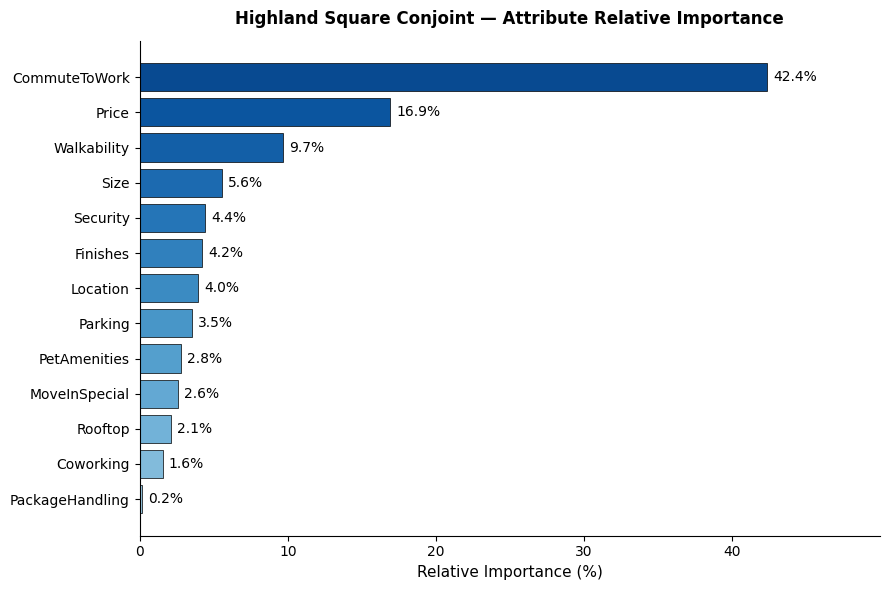


Saved: data/relative_importance.png


In [20]:
# Plot relative importance — APA style
fig, ax = plt.subplots(figsize=(9, 6))
colors = plt.cm.Blues(np.linspace(0.4, 0.9, len(importance_df)))
ax.barh(importance_df.index, importance_df['pct'], color=colors, edgecolor='black', linewidth=0.5)
for i, (attr, row) in enumerate(importance_df.iterrows()):
    ax.text(row['pct'] + 0.4, i, f"{row['pct']:.1f}%", va='center', fontsize=10)
ax.set_xlabel('Relative Importance (%)', fontsize=11)
ax.set_title('Highland Square Conjoint — Attribute Relative Importance',
             fontsize=12, fontweight='bold', pad=12)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_xlim(0, importance_df['pct'].max() * 1.18)
plt.tight_layout()
plt.savefig(DATA_DIR / 'relative_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"\nSaved: {DATA_DIR / 'relative_importance.png'}")

### 6b. Zero-Centered Part-Worth Utilities (per attribute)

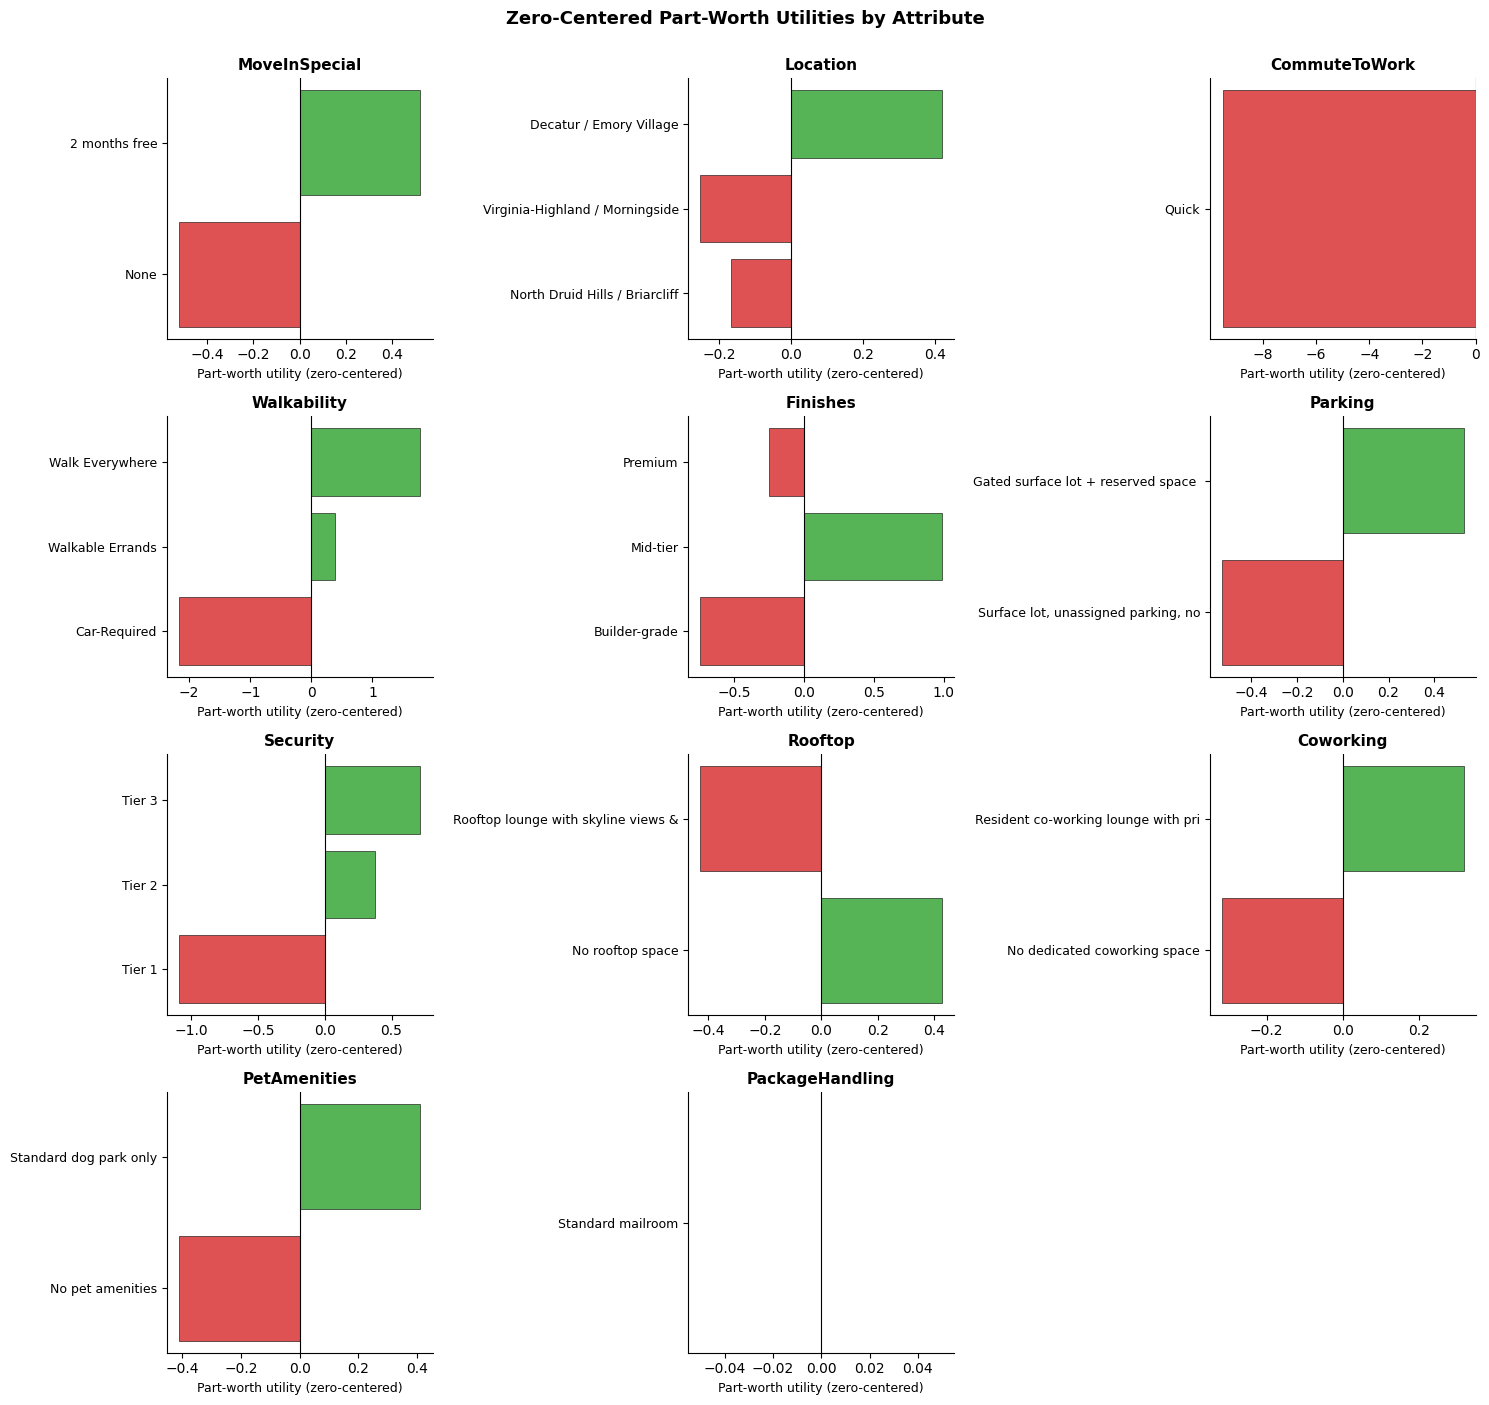


Saved: data/part_worth_utilities.png


In [21]:
# For each categorical attribute, plot all levels (including the baseline as 0)
# zero-centered means we subtract the attribute's mean

cat_attrs_to_plot = [a for a in CATEGORICAL_ATTRS if a in attr_names]
n_attrs = len(cat_attrs_to_plot)
n_cols = 3
n_rows = int(np.ceil(n_attrs / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 3.5 * n_rows))
axes = axes.flatten() if n_attrs > 1 else [axes]

for idx, attr in enumerate(cat_attrs_to_plot):
    ax = axes[idx]
    # Get all levels for this attribute
    levels = list(ATTRIBUTES[attr].keys())
    baseline = levels[0]
    
    # Coefficients (baseline = 0)
    coefs = {baseline: 0.0}
    for c in dummy_cols:
        if c.startswith(f"{attr}__"):
            level = c.replace(f"{attr}__", "")
            coefs[level] = coef_df.loc[coef_df['feature'] == c, 'coef'].values[0]
    
    # Zero-center
    mean_coef = np.mean(list(coefs.values()))
    centered = {l: c - mean_coef for l, c in coefs.items()}
    
    # Plot (preserve original level order)
    level_order = [l for l in levels if l in centered]
    values = [centered[l] for l in level_order]
    short_labels = [l.split(' (')[0].split(':')[0][:35] for l in level_order]
    
    colors = ['#d62728' if v < 0 else '#2ca02c' for v in values]
    ax.barh(short_labels, values, color=colors, edgecolor='black', linewidth=0.5, alpha=0.8)
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_title(attr, fontsize=11, fontweight='bold')
    ax.set_xlabel('Part-worth utility (zero-centered)', fontsize=9)
    ax.tick_params(axis='y', labelsize=9)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

# Hide unused axes
for idx in range(len(cat_attrs_to_plot), len(axes)):
    axes[idx].axis('off')

plt.suptitle('Zero-Centered Part-Worth Utilities by Attribute',
             fontsize=13, fontweight='bold', y=1.00)
plt.tight_layout()
plt.savefig(DATA_DIR / 'part_worth_utilities.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"\nSaved: {DATA_DIR / 'part_worth_utilities.png'}")

### 6c. Dollar Willingness-to-Pay per Level

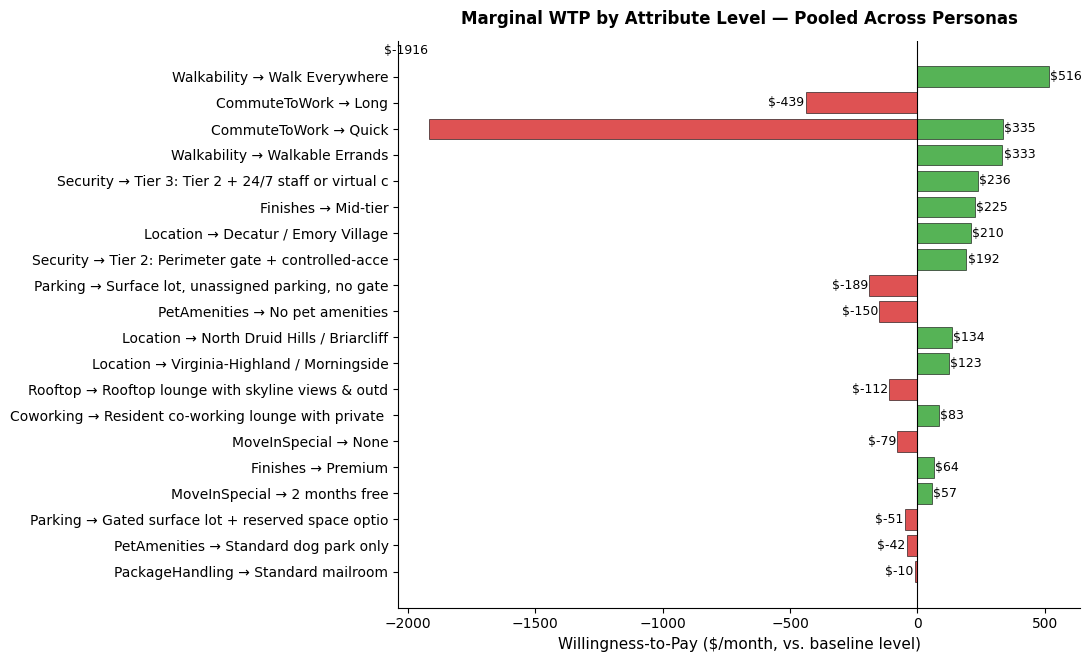


Saved: data/wtp_dollars.png


In [22]:
# Plot WTP in dollars/month for each categorical level (vs. baseline)
wtp_cat = wtp_df[wtp_df['attribute'].isin(CATEGORICAL_ATTRS)].copy()
wtp_cat = wtp_cat.sort_values('WTP_$/mo', key=abs, ascending=True)
wtp_cat['label'] = wtp_cat['attribute'] + ' → ' + wtp_cat['level'].str.split(r' \(').str[0].str[:40]

fig, ax = plt.subplots(figsize=(11, max(6, 0.32 * len(wtp_cat))))
colors = ['#d62728' if v < 0 else '#2ca02c' for v in wtp_cat['WTP_$/mo']]
ax.barh(wtp_cat['label'], wtp_cat['WTP_$/mo'], color=colors, edgecolor='black', linewidth=0.5, alpha=0.8)
ax.axvline(0, color='black', linewidth=0.8)
for i, (_, row) in enumerate(wtp_cat.iterrows()):
    offset = 5 if row['WTP_$/mo'] >= 0 else -5
    align = 'left' if row['WTP_$/mo'] >= 0 else 'right'
    ax.text(row['WTP_$/mo'] + offset, i, f"${row['WTP_$/mo']:.0f}",
            va='center', ha=align, fontsize=9)
ax.set_xlabel('Willingness-to-Pay ($/month, vs. baseline level)', fontsize=11)
ax.set_title('Marginal WTP by Attribute Level — Pooled Across Personas',
             fontsize=12, fontweight='bold', pad=12)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig(DATA_DIR / 'wtp_dollars.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"\nSaved: {DATA_DIR / 'wtp_dollars.png'}")

## 7. Per-Persona Models (Segment-Specific WTP)

Run the same multinomial logit separately for each persona to get cohort-specific coefficients. This is what we'll feed into the market-share simulator weighted by demographic population shares.

In [23]:
persona_coefs = {}

for persona in long_df_encoded['Persona'].unique():
    sub = long_df_encoded[long_df_encoded['Persona'] == persona].copy()
    if len(sub) < 100:
        print(f"Skipping {persona}: too few observations")
        continue
    
    X_p = sub[feature_cols].values.astype(float)
    y_p = sub['choice'].values.astype(int)
    obs_p = sub['ObsID'].values
    alt_p = sub['Alt'].values
    
    print(f"\n=== {persona} (n_obs={sub['ObsID'].nunique()}) ===")
    model = MultinomialLogit()
    try:
        model.fit(X=X_p, y=y_p, varnames=feature_cols, ids=obs_p, alts=alt_p)
        persona_coefs[persona] = pd.DataFrame({
            'feature': feature_cols,
            'coef': model.coeff_,
            'p_value': model.pvalues,
        })
        b_price = persona_coefs[persona].loc[persona_coefs[persona]['feature'] == 'Price_num', 'coef'].values[0]
        print(f"  β_price: {b_price:.6f} | Implied $1k of utility = ${1000/abs(b_price):.0f}/mo" if b_price < 0 else f"  β_price: {b_price:.6f} ⚠")
    except Exception as e:
        print(f"  Failed: {e}")

print(f"\nFit {len(persona_coefs)} per-persona models.")


=== emory_grad (n_obs=1800) ===
  β_price: -0.009317 | Implied $1k of utility = $107328/mo

=== vahi_professional (n_obs=1800) ===
  β_price: -0.019440 | Implied $1k of utility = $51441/mo

=== empty_nester (n_obs=1800) ===
  β_price: -0.005742 | Implied $1k of utility = $174163/mo

=== skeptical_renter_control (n_obs=1800) ===
  β_price: -0.015815 | Implied $1k of utility = $63233/mo

Fit 4 per-persona models.


In [24]:
# Build per-persona WTP table for a key set of attributes
key_features = [
    'Location__Buckhead / Lenox',
    'Location__Virginia-Highland / Morningside',
    'Walkability__Walk Everywhere (daily errands, dining, transit within a 10-min walk of this building)',
    'Security__Tier 3: Tier 2 + 24/7 staff or virtual concierge + smart locks throughout',
    'Finishes__Premium (quartz waterfall island, smart thermostat, keyless entry, video doorbell)',
    'Parking__Dedicated garage with assigned space + EV charging',
    'Rooftop__Rooftop lounge with skyline views & outdoor seating',
    'Coworking__Resident co-working lounge with private call rooms & wifi',
    'PackageHandling__24/7 Amazon Hub lockers + refrigerated grocery locker',
]

compare_rows = []
for persona, pdf in persona_coefs.items():
    b_price = pdf.loc[pdf['feature'] == 'Price_num', 'coef'].values[0]
    if b_price >= 0:
        continue
    for feat in key_features:
        b = pdf.loc[pdf['feature'] == feat, 'coef'].values[0] if feat in pdf['feature'].values else np.nan
        compare_rows.append({
            'persona': persona,
            'feature': feat.split('__', 1)[1][:45],
            'WTP_$/mo': -b / b_price if not np.isnan(b) else np.nan,
        })

compare_df = pd.DataFrame(compare_rows)
pivot = compare_df.pivot(index='feature', columns='persona', values='WTP_$/mo').round(0)
print("\nWTP by Persona ($/month vs. baseline level):\n")
print(pivot.fillna('—'))


WTP by Persona ($/month vs. baseline level):

persona                                       emory_grad empty_nester  \
feature                                                                 
24/7 Amazon Hub lockers + refrigerated grocer          —            —   
Buckhead / Lenox                                       —            —   
Dedicated garage with assigned space + EV cha          —            —   
Premium (quartz waterfall island, smart therm        6.0        243.0   
Resident co-working lounge with private call       111.0          4.0   
Rooftop lounge with skyline views & outdoor s      -67.0         34.0   
Tier 3: Tier 2 + 24/7 staff or virtual concie       82.0        180.0   
Virginia-Highland / Morningside                     60.0        265.0   
Walk Everywhere (daily errands, dining, trans      324.0        892.0   

persona                                       skeptical_renter_control  \
feature                                                                  
2

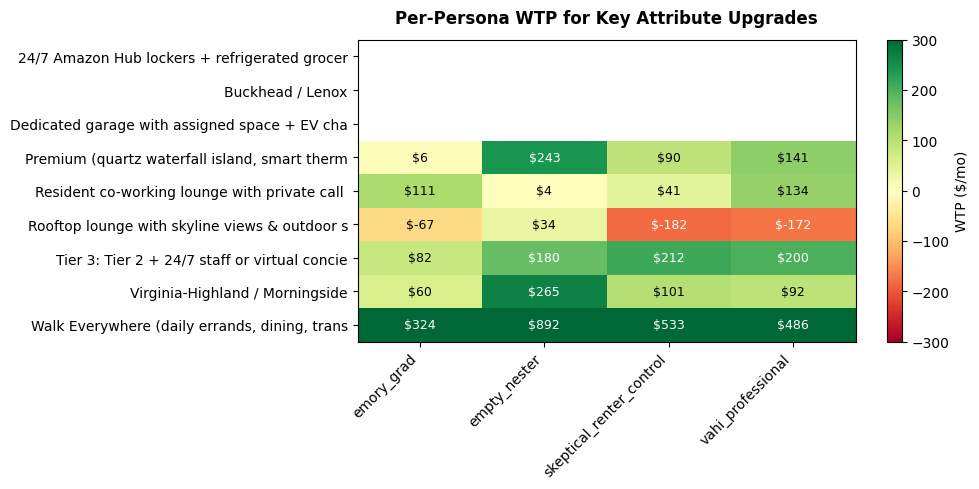


Saved: data/persona_wtp_heatmap.png


In [25]:
# Plot per-persona WTP heatmap
fig, ax = plt.subplots(figsize=(10, max(5, 0.5 * len(pivot))))
data = pivot.values.astype(float)
im = ax.imshow(data, cmap='RdYlGn', aspect='auto', vmin=-300, vmax=300)
ax.set_xticks(range(len(pivot.columns)))
ax.set_xticklabels(pivot.columns, rotation=45, ha='right')
ax.set_yticks(range(len(pivot.index)))
ax.set_yticklabels(pivot.index)
for i in range(data.shape[0]):
    for j in range(data.shape[1]):
        v = data[i, j]
        if not np.isnan(v):
            ax.text(j, i, f"${v:.0f}", ha='center', va='center', fontsize=9,
                    color='white' if abs(v) > 150 else 'black')
plt.colorbar(im, ax=ax, label='WTP ($/mo)')
ax.set_title('Per-Persona WTP for Key Attribute Upgrades', fontsize=12, fontweight='bold', pad=12)
plt.tight_layout()
plt.savefig(DATA_DIR / 'persona_wtp_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"\nSaved: {DATA_DIR / 'persona_wtp_heatmap.png'}")

## 8. Market-Share Simulator

Given a set of competing properties, the simulator computes the probability that each persona chooses each one (or the outside option), then weights by demographic population shares to produce overall market share.

In [26]:
def property_utility(profile, coefs, attr_names, ATTRIBUTES, dummy_cols):
    """Compute the deterministic utility of a single property profile under a given coef vector."""
    util = 0.0
    # Continuous
    util += coefs.loc[coefs['feature'] == 'Size_num', 'coef'].values[0] * ATTRIBUTES['Size'][profile['Size']]
    util += coefs.loc[coefs['feature'] == 'Price_num', 'coef'].values[0] * ATTRIBUTES['Price'][profile['Price']]
    # Categorical dummies
    for attr in attr_names:
        if attr in ('Size', 'Price'):
            continue
        level = profile[attr]
        baseline = list(ATTRIBUTES[attr].keys())[0]
        if level == baseline:
            continue
        feat = f"{attr}__{level}"
        match = coefs.loc[coefs['feature'] == feat, 'coef']
        if len(match) > 0:
            util += match.values[0]
    return util

def outside_option_utility(coefs):
    """Utility of the D / 'keep searching' option = the ASC_D coefficient."""
    return coefs.loc[coefs['feature'] == 'ASC_D', 'coef'].values[0]

def market_share(competing_profiles, coefs, attr_names, ATTRIBUTES, dummy_cols,
                 include_outside=True):
    """Softmax over competing properties (+ outside option) to get choice probabilities."""
    utilities = [property_utility(p, coefs, attr_names, ATTRIBUTES, dummy_cols) for p in competing_profiles]
    labels = [p.get('Name', f'Property {i+1}') for i, p in enumerate(competing_profiles)]
    if include_outside:
        utilities.append(outside_option_utility(coefs))
        labels.append('Keep searching (outside option)')
    utilities = np.array(utilities)
    exp_u = np.exp(utilities - utilities.max())  # numerical stability
    shares = exp_u / exp_u.sum()
    return pd.DataFrame({'option': labels, 'utility': utilities.round(3), 'share_pct': (shares * 100).round(2)})

print("Simulator functions defined.")

Simulator functions defined.


In [27]:
# Define competing scenarios — modify these as needed for the IC memo
highland_square_current = {
    'Name': 'Highland Square (subject, current state)',
    'Size': '1,000 SF (large 1BR / compact 2BR)',
    'Price': '$1,950/mo',
    'MoveInSpecial': '1 month free (12-mo lease)',
    'Location': 'North Druid Hills / Briarcliff',
    'CommuteToWork': 'Average (15-30 minutes to your daily destination)',
    'Walkability': 'Walkable Errands (groceries & a few restaurants within a 10-min walk of this building)',
    'Finishes': 'Mid-tier (granite/quartz counters, stainless appliances, in-unit washer/dryer)',
    'Parking': 'Gated surface lot + reserved space option',
    'Security': 'Tier 2: Perimeter gate + controlled-access lobby + camera coverage',
    'Rooftop': 'No rooftop space',
    'Coworking': 'No dedicated coworking space',
    'PetAmenities': 'Standard dog park only',
    'PackageHandling': 'Standard mailroom (sign for packages during office hours)',
}

highland_square_repositioned = {
    **highland_square_current,
    'Name': 'Highland Square (post-renovation: +rooftop +finishes +security)',
    'Price': '$2,250/mo',  # post-reno rent uplift
    'Finishes': 'Premium (quartz waterfall island, smart thermostat, keyless entry, video doorbell)',
    'Rooftop': 'Rooftop lounge with skyline views & outdoor seating',
    'Coworking': 'Resident co-working lounge with private call rooms & wifi',
    'Security': 'Tier 3: Tier 2 + 24/7 staff or virtual concierge + smart locks throughout',
    'PackageHandling': '24/7 Amazon Hub lockers + refrigerated grocery locker',
}

modera_morningside_comp = {
    'Name': 'Modera Morningside (key comp)',
    'Size': '1,000 SF (large 1BR / compact 2BR)',
    'Price': '$2,250/mo',
    'MoveInSpecial': 'None',
    'Location': 'Virginia-Highland / Morningside',
    'CommuteToWork': 'Average (15-30 minutes to your daily destination)',
    'Walkability': 'Walk Everywhere (daily errands, dining, transit within a 10-min walk of this building)',
    'Finishes': 'Premium (quartz waterfall island, smart thermostat, keyless entry, video doorbell)',
    'Parking': 'Dedicated garage with assigned space + EV charging',
    'Security': 'Tier 3: Tier 2 + 24/7 staff or virtual concierge + smart locks throughout',
    'Rooftop': 'Rooftop lounge with skyline views & outdoor seating',
    'Coworking': 'Resident co-working lounge with private call rooms & wifi',
    'PetAmenities': 'Dog park + pet spa with grooming station',
    'PackageHandling': '24/7 Amazon Hub lockers + refrigerated grocery locker',
}

competing_set = [highland_square_current, modera_morningside_comp]

print("=== SCENARIO 1: Highland Square (current) vs. Modera ===\n")
for persona, pdf in persona_coefs.items():
    b_price = pdf.loc[pdf['feature'] == 'Price_num', 'coef'].values[0]
    if b_price >= 0:
        continue
    print(f"\nFrom {persona}'s perspective:")
    print(market_share(competing_set, pdf, attr_names, ATTRIBUTES, dummy_cols).to_string(index=False))

=== SCENARIO 1: Highland Square (current) vs. Modera ===


From emory_grad's perspective:
                                  option  utility  share_pct
Highland Square (subject, current state)  -11.938      68.51
           Modera Morningside (key comp)  -12.728      31.08
         Keep searching (outside option)  -17.069       0.40

From vahi_professional's perspective:
                                  option  utility  share_pct
Highland Square (subject, current state)  -23.349       6.98
           Modera Morningside (key comp)  -20.778      91.35
         Keep searching (outside option)  -24.783       1.66

From empty_nester's perspective:
                                  option  utility  share_pct
Highland Square (subject, current state)    0.795       8.48
           Modera Morningside (key comp)    3.174      91.52
         Keep searching (outside option)  -10.638       0.00

From skeptical_renter_control's perspective:
                                  option  utility  share_pc

In [28]:
# Scenario 2: After repositioning
competing_set_repositioned = [highland_square_repositioned, modera_morningside_comp]

print("=== SCENARIO 2: Highland Square (repositioned, +$300/mo rent) vs. Modera ===\n")
for persona, pdf in persona_coefs.items():
    b_price = pdf.loc[pdf['feature'] == 'Price_num', 'coef'].values[0]
    if b_price >= 0:
        continue
    print(f"\nFrom {persona}'s perspective:")
    print(market_share(competing_set_repositioned, pdf, attr_names, ATTRIBUTES, dummy_cols).to_string(index=False))

=== SCENARIO 2: Highland Square (repositioned, +$300/mo rent) vs. Modera ===


From emory_grad's perspective:
                                                         option  utility  share_pct
Highland Square (post-renovation: +rooftop +finishes +security)  -14.070      20.50
                                  Modera Morningside (key comp)  -12.728      78.48
                                Keep searching (outside option)  -17.069       1.02

From vahi_professional's perspective:
                                                         option  utility  share_pct
Highland Square (post-renovation: +rooftop +finishes +security)  -29.847       0.01
                                  Modera Morningside (key comp)  -20.778      98.20
                                Keep searching (outside option)  -24.783       1.79

From empty_nester's perspective:
                                                         option  utility  share_pct
Highland Square (post-renovation: +rooftop +finishes +securit

In [29]:
# Population-weighted share — combine personas using ACS-like demographic weights
# These are placeholder weights; replace with actual ACS / AxleData for the trade area
POPULATION_WEIGHTS = {
    'emory_grad': 0.20,             # Emory students/postdocs in the trade area
    'vahi_professional': 0.40,      # Mid-career professionals (largest segment)
    'empty_nester': 0.20,           # Downsizing households
    'skeptical_renter_control': 0.20,  # Analytical comparison shoppers
}
assert abs(sum(POPULATION_WEIGHTS.values()) - 1.0) < 1e-6, "Weights must sum to 1"

def weighted_market_share(competing_profiles, persona_coefs, weights, attr_names, ATTRIBUTES, dummy_cols):
    """Population-weighted share across personas."""
    combined = {}
    for persona, w in weights.items():
        if persona not in persona_coefs:
            continue
        pdf = persona_coefs[persona]
        if pdf.loc[pdf['feature'] == 'Price_num', 'coef'].values[0] >= 0:
            continue  # skip personas with non-negative price coef
        df_share = market_share(competing_profiles, pdf, attr_names, ATTRIBUTES, dummy_cols)
        for _, r in df_share.iterrows():
            combined[r['option']] = combined.get(r['option'], 0) + w * r['share_pct']
    return pd.DataFrame({'option': list(combined.keys()), 'share_pct': list(combined.values())}).round(2)

print("=== POPULATION-WEIGHTED MARKET SHARE ===\n")
print("Scenario 1: Current state")
print(weighted_market_share(competing_set, persona_coefs, POPULATION_WEIGHTS, attr_names, ATTRIBUTES, dummy_cols).to_string(index=False))
print("\nScenario 2: Post-repositioning")
print(weighted_market_share(competing_set_repositioned, persona_coefs, POPULATION_WEIGHTS, attr_names, ATTRIBUTES, dummy_cols).to_string(index=False))

=== POPULATION-WEIGHTED MARKET SHARE ===

Scenario 1: Current state
                                  option  share_pct
Highland Square (subject, current state)      28.99
           Modera Morningside (key comp)      70.15
         Keep searching (outside option)       0.86

Scenario 2: Post-repositioning
                                                         option  share_pct
Highland Square (post-renovation: +rooftop +finishes +security)       4.27
                                  Modera Morningside (key comp)      94.56
                                Keep searching (outside option)       1.17


## 9. Summary Tables for the IC Memo

In [30]:
# Top 5 positive and top 5 negative WTP drivers (pooled model)
wtp_sorted = wtp_df.sort_values('WTP_$/mo', ascending=False)
print("=== TOP 5 POSITIVE WTP DRIVERS ===\n")
print(wtp_sorted.head(5)[['attribute', 'level', 'WTP_$/mo', 'p_value']].to_string(index=False))
print("\n=== TOP 5 NEGATIVE WTP DRIVERS ===\n")
print(wtp_sorted.tail(5)[['attribute', 'level', 'WTP_$/mo', 'p_value']].to_string(index=False))

=== TOP 5 POSITIVE WTP DRIVERS ===

    attribute                                                                                  level  WTP_$/mo  p_value
  Walkability Walk Everywhere (daily errands, dining, transit within a 10-min walk of this building)    516.37      0.0
CommuteToWork                                                            Quick (under 15 min by car)    335.37      0.0
  Walkability Walkable Errands (groceries & a few restaurants within a 10-min walk of this building)    333.21      0.0
     Security              Tier 3: Tier 2 + 24/7 staff or virtual concierge + smart locks throughout    236.32      0.0
     Finishes         Mid-tier (granite/quartz counters, stainless appliances, in-unit washer/dryer)    225.24      0.0

=== TOP 5 NEGATIVE WTP DRIVERS ===

             attribute                                              level  WTP_$/mo  p_value
          PetAmenities                                   No pet amenities   -149.90      0.0
               Parkin

In [31]:
# Save consolidated outputs
wtp_df.to_csv(DATA_DIR / 'wtp_table.csv', index=False)
importance_df.to_csv(DATA_DIR / 'relative_importance.csv')
if len(persona_coefs) > 0:
    pivot.to_csv(DATA_DIR / 'persona_wtp.csv')

print("Saved analysis outputs to data/:")
print("  - wtp_table.csv")
print("  - relative_importance.csv")
print("  - persona_wtp.csv")
print("  - relative_importance.png")
print("  - part_worth_utilities.png")
print("  - wtp_dollars.png")
print("  - persona_wtp_heatmap.png")
print("\nReady for IC memo.")

Saved analysis outputs to data/:
  - wtp_table.csv
  - relative_importance.csv
  - persona_wtp.csv
  - relative_importance.png
  - part_worth_utilities.png
  - wtp_dollars.png
  - persona_wtp_heatmap.png

Ready for IC memo.


In [32]:
# Inspect what CommuteToWork values actually appear in your raw data
import json
all_commutes = []
for prof_json in df['Profiles']:
    profiles = prof_json if isinstance(prof_json, list) else json.loads(prof_json)
    for p in profiles:
        all_commutes.append(p['CommuteToWork'])

from collections import Counter
print("Unique CommuteToWork values in raw_responses.csv:")
for val, count in Counter(all_commutes).most_common():
    print(f"  {count:5d}  {val}")

Unique CommuteToWork values in raw_responses.csv:
   7200  Average (15-30 min by car)
   7200  Quick (under 15 min by car)
   7200  Long (over 30 min by car)
